In [750]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib as mpl
from mpl_toolkits.axes_grid1.axes_divider import make_axes_locatable

In [751]:
xplot = np.linspace(0, 28, 560)
yplot = np.linspace(0, 20, 400)

X, Y = np.meshgrid(xplot, yplot, indexing='xy')

In [752]:
def dist(x,y,u,v):
    return np.sqrt((x-u)**2+(y-v)**2)

def func(x):
    return np.pow(x,1)

def potencial(X,Y):
    diferenciaPotencial = 19
    radioEsferico = 0.5

    offsetPotencial = diferenciaPotencial/2

    distanceUno = dist(X, Y, 7, 10)
    distanceDos = dist(X, Y, 21, 10)

    constantePotencial = func(radioEsferico)*diferenciaPotencial/2

    return np.where(distanceUno < radioEsferico,
                    -diferenciaPotencial/2,
                    np.where(distanceDos < radioEsferico,
                             diferenciaPotencial/2,
                             -constantePotencial/func(distanceUno) + constantePotencial/func(distanceDos))
                    ) + offsetPotencial

    '''if (dist(x,y,7,10) < 0.1):
        return 0
    else:
        if (dist(x,y,21,10) < 0.1):
            return 19
        else:
            return -10/(dist(x,y,7,10)+0.5) + 10/(dist(x,y,21,10)+0.5)'''


In [753]:
data = potencial(X,Y)

In [754]:
fieldGradient = -np.array(np.gradient(data))

In [755]:
normMatrix = np.sqrt(fieldGradient[0]**2 + fieldGradient[1]**2)
normalizedFieldGradientU = fieldGradient[0]/normMatrix
normalizedFieldGradientV = fieldGradient[1]/normMatrix

C:\Users\Alex\AppData\Local\Temp\ipykernel_4428\3781656896.py:2: RuntimeWarning: invalid value encountered in divide
  normalizedFieldGradientU = fieldGradient[0]/normMatrix
C:\Users\Alex\AppData\Local\Temp\ipykernel_4428\3781656896.py:3: RuntimeWarning: invalid value encountered in divide
  normalizedFieldGradientV = fieldGradient[1]/normMatrix


In [756]:
colors = ["#03071e","#370617","#6a040f","#9d0208","#d00000","#dc2f02","#e85d04","#f48c06","#faa307"]
red_orange_cmap = mpl.colors.LinearSegmentedColormap.from_list("red_orange", colors)

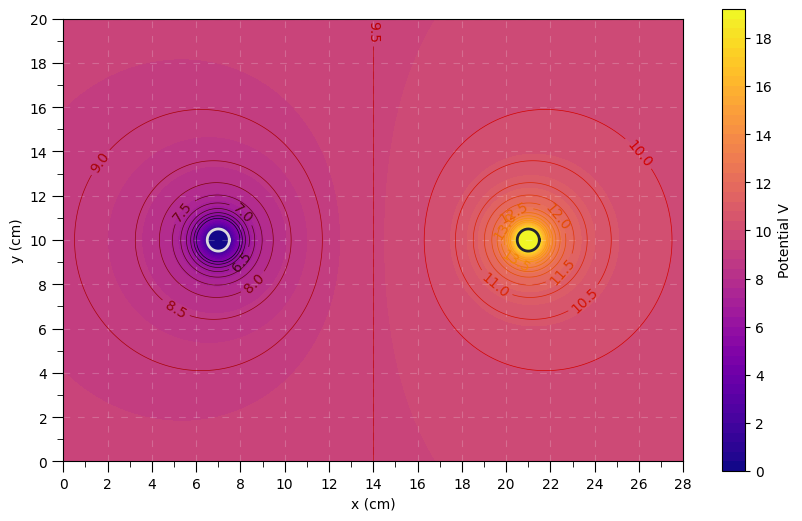

In [757]:
chargePositions = np.array([[7,10],[21,10]])
chargeColors = ["gainsboro","#232330"]

fig, ax = plt.subplots(figsize=(10, 6))


levels = np.linspace(5,15,21)

#img = ax.imshow(data, aspect='equal', cmap = "plasma", origin = "lower", interpolation = "nearest", extent = (0,28,0,20))

testytest = cf = plt.contourf(X, Y, data, levels=50, cmap='plasma')
plt.colorbar(cf, label='Potential V')

CS = ax.contour(X, Y, data, levels = levels, cmap = red_orange_cmap, zorder = 2,  linewidths = 0.5)
ax.clabel(CS, levels[3:-3], fontsize = 10)

#ax.scatter(chargePositions[:,0], chargePositions[:,1], c = chargeColors, zorder = 15)


c1 = (7.0, 10.0)               # center of left circle
c2 = (21.0, 10.0)              # center of right circle
R = 0.5                       # radius of both circles
theta = np.linspace(0, 2*np.pi, 400)
plt.plot(c1[0] + R*np.cos(theta), c1[1] + R*np.sin(theta), "gainsboro", linewidth=2)
plt.plot(c2[0] + R*np.cos(theta), c2[1] + R*np.sin(theta), "#232330", linewidth=2)

ax.set_aspect('equal')

ax.set_xticks(np.arange(0, 29, 2))
ax.set_xticks(np.arange(1, 29, 2), minor=True)

ax.tick_params(axis='x', which='major', length=8)
ax.tick_params(axis='x', which='minor', length=4)

ax.set_yticks(np.arange(0, 21, 2))
ax.set_yticks(np.arange(1, 21, 2), minor=True)

ax.tick_params(axis='y', which='major', length=8)
ax.tick_params(axis='y', which='minor', length=4)

ax.grid(color = "#FFFFFF", zorder = 1, alpha = 0.2, ls = (0,(6,7)))

ax.set_xlabel("x (cm)")
ax.set_ylabel("y (cm)")
'''
cax = divider.append_axes("right", size="3%", pad=0.0)
cbar = plt.colorbar(sc, cax=cax)
cbar.set_label('Voltaje (V)',rotation=-90,  labelpad=15)'''


plt.savefig("casoUnoEquipotencialesDipolo.png", dpi = 300)
plt.show()

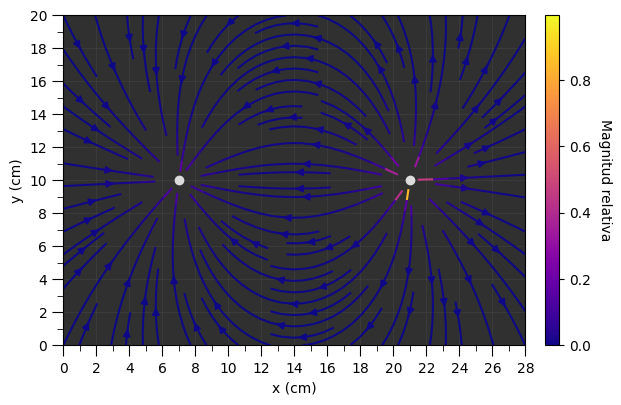

In [758]:
fig, ax = plt.subplots()

divider = make_axes_locatable(ax)

#skip = (slice(None, None, 20), slice(None, None, 20))
#ax.quiver(Y[skip],X[skip], normalizedFieldGradientV[skip], normalizedFieldGradientU[skip], fieldGradient[1][skip]*fieldGradient[0][skip], angles='xy', scale_units='xy', scale = 1, cmap = 'rainbow', pivot = "mid")
isStreamlineBroken = True

normalizationFactor = np.max(fieldGradient[1]*fieldGradient[0])

stream = plt.streamplot(X,Y,fieldGradient[1], fieldGradient[0],
               color = np.sqrt(fieldGradient[1]**2+fieldGradient[0]**2),
               density = 1, cmap = "plasma",
               broken_streamlines = isStreamlineBroken,
               )
ax.scatter(chargePositions[:,0], chargePositions[:,1], c = "gainsboro", zorder = 10)

cax = divider.append_axes("right", size="3%", pad=0.2)
cbar = fig.colorbar(stream.lines, cax=cax)
cbar.set_label('Magnitud relativa',rotation=-90,  labelpad=15)

ax.set_xticks(np.arange(0, 29, 2))
ax.set_xticks(np.arange(1, 29, 2), minor=True)

ax.tick_params(axis='x', which='major', length=8)
ax.tick_params(axis='x', which='minor', length=4)

ax.set_yticks(np.arange(0, 21, 2))
ax.set_yticks(np.arange(1, 21, 2), minor=True)

ax.tick_params(axis='y', which='major', length=8)
ax.tick_params(axis='y', which='minor', length=4)

ax.grid(color = "#666666", zorder = 10, alpha = 0.2, ls = "solid")

ax.set_xlabel("x (cm)")
ax.set_ylabel("y (cm)")

ax.set_aspect("equal")

ax.set_facecolor('#303030')


plt.savefig(f"casoUnoCampoElectricoDipolo{isStreamlineBroken}.png", dpi = 300)
plt.show()

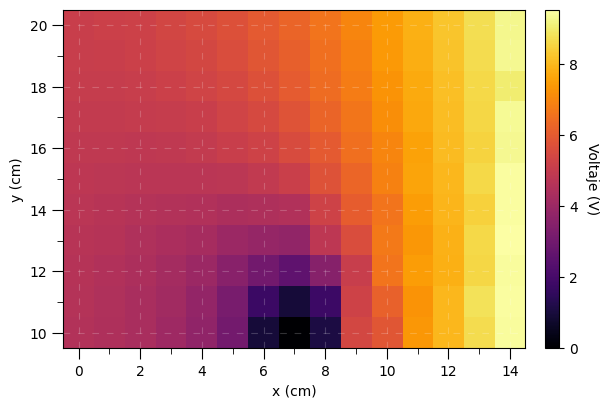

In [759]:
fig, ax = plt.subplots()
divider = make_axes_locatable(ax)

offsetX = 0
offsetY = 10

img = ax.imshow(dataArray, aspect='equal', cmap = "inferno", origin = "upper", interpolation = "none", extent = (-0.5+offsetX,14.5+offsetX,-0.5+offsetY,10.5+offsetY))


cax = divider.append_axes("right", size="3%", pad=0.2)
cbar = fig.colorbar(img, cax=cax)
cbar.set_label('Voltaje (V)',rotation=-90,  labelpad=15)


ax.set_xticks(np.arange(0+offsetX, 15+offsetX, 2))
ax.set_xticks(np.arange(1+offsetX, 15+offsetX, 2), minor=True)

ax.tick_params(axis='x', which='major', length=8)
ax.tick_params(axis='x', which='minor', length=4)

ax.set_yticks(np.arange(0+offsetY, 11+offsetY, 2))
ax.set_yticks(np.arange(1+offsetY, 11+offsetY, 2), minor=True)

ax.tick_params(axis='y', which='major', length=8)
ax.tick_params(axis='y', which='minor', length=4)

ax.grid(color = "#FFFFFF", zorder = 1, alpha = 0.2, ls = (0,(6,7)))

ax.set_xlabel("x (cm)")
ax.set_ylabel("y (cm)")

plt.savefig("casoUnoPreprocesado.png", dpi = 300)

plt.show()

ValueError: One of the requested xi is out of bounds in dimension 0

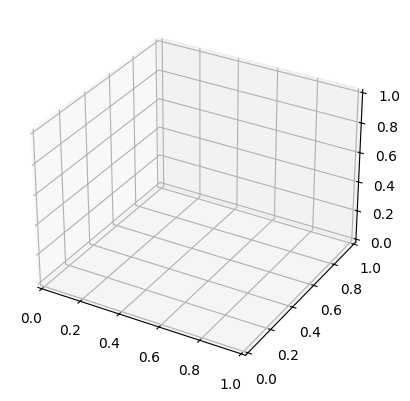

In [760]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')

ax.plot_wireframe(X, Y, interp((X, Y)), rstride=3, cstride=3,
                  alpha=0.4, color='m', label='linear interp')

plt.show()

In [ ]:
fig, ax = plt.subplots()

cp = ax.contour(Y, X, data, levels = 20, cmap = 'viridis')